# Hybrid Quantum-Classical Reinforcement Learning (1/3)

___
___

## Introduction
___

This experiment is based on the 2025 paper by Nagy et al.: "[Hybrid Quantum-Classical Reinforcement Learning in Latent Observation Spaces](https://arxiv.org/abs/2410.18284)".

In this article, the authors apply hybrid quantum-classical Reinforcement Learning (RL) models to two simulated environments. They compare classical, qubit-based and photonic-based agents, all using Proximal Policy Optimization (PPO). They also use an AutoEncoder (AE) to compress the dimensionality of the observations and train that AE jointly with the PPO agents.

Part I: Cart Pole environment - Classical vs Qubit
Parit II: Two bigger environments (Long runtime)
Part III: Photonic (deprecated SF)

In this first notebook will present:
1. Cart Pole environment
2. AutoEncoders
3. Classical PPO agent
4. Qubit-based PPO agent
5. The results of the agents on the environment
6. Conclusions
7. Follow-ups


In [1]:
# !pip install torch torchvision gymnasium swig "gymnasium[box2d]" matplotlib pennylane
import datetime
import random
from collections import namedtuple, deque
from itertools import count
import resource
import platform
import numpy as np
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
import pennylane as qp

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "cpu"
)

## 1 - RL Environment: Cart Pole
___

In the article, the authors use two environments: CartPole-v1 (OpenAI Gym) and Maze-v0 (custom environment). For this experiment to run in required time, we will use CartPole-v1 only.

But first, a small refresher on Reinforcement Learning: in this sub-field of Machine Learning, an agent interacts with an environment and learns a Policy.

<div align="center">
<img src="images/qrl_demo_rl.png" width="800"/>
</div>

At each moment, the state of the environment is observed and the agent chooses an action accordingly. This action changes the environment, which gives a reward (depending on how good that action was for the overall objective) and the new state. The agent must learn to choose the best actions depending on the environment's state, in order to maximize the cumulative reward.

### Cart Pole

<div align="center">
<img src="images/qrl_demo_cartpole.gif" width="300"/>
</div>

In this Classic Control environment, the agent must learn to balance a pole on top of a cart by moving the cart left and right. 

At each step, the agent receives 4 observations: the cart's position, its velocity, the pole's angle and the pole's angular velocity. From these observations, it must then choose between 2 actions: push the cart to the left or push the cart to the right.

The agent receives a +1 reward for each step where the pole is considered balanced (pole's angle greater than ±12°). The simulation (episode) ends when the pole is no longer balanced, when the cart's position is getting out of display or when the episode is > 500 steps.

More details about this environment can be found here: https://gymnasium.farama.org/environments/classic_control/cart_pole/.

In [2]:
# Create the Cart Pole environment
cartpole_env = gym.make("CartPole-v1", render_mode="rgb_array")
cartpole_env.reset(seed=seed)
cartpole_env.action_space.seed(seed)
cartpole_env.observation_space.seed(seed)

42

## 2 - AutoEncoders (AEs)
___

The Cart Pole environment contains 4 observations which can be reduced to 2 variables with an AE.

AEs are used for dimensionality reduction, data compression and feature learning. They are composed of an encoder which produces a compressed representation of the original data, and a decoder which reconstructs the original data from the compressed, latent space representation.

<div align="center">
<img src="images/qrl_demo_autoencoder.png" width="800"/>
</div>

As such, AEs learn to create a relevant low-dimensional latent space representation of the original data. This is useful for quantum computing as it reduces the amount of data nodes (qubits/qumodes) needed and therefore computational cost.

Though AEs are usually trained in an unsupervised manner, learning to reconstruct the original data by themselves, the article's approach is different. Here, the authors choose to train the encoder part of the AE only, jointly with the PPO agents. This ensures that the latent space representation learned by the AE is specifically suited to the RL problem.

In [3]:
class EncoderDecoderNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.layer3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.layer1(x)
        x = F.relu(x)
        x = self.layer2(x)
        x = F.relu(x)
        return self.layer3(x)

class AutoEncoder(nn.Module):
    def __init__(self, input_dim, parameters):
        super().__init__()
        self.encoder = EncoderDecoderNN(input_dim, parameters["ae_hidden_dim"], parameters["ae_output_dim"])
        self.decoder = EncoderDecoderNN(parameters["ae_output_dim"], parameters["ae_hidden_dim"], input_dim)

## 3 - Classical PPO
___

The classical framework of Proximal Policy Optimization involves two neural networks (NNs): the Actor and the Critic. At each step, the Actor receives the compressed observations of the environment from the AE (state), and outputs a probability distribution over the possible actions. An action is sampled from this distribution and executed in the environment. 

The environment gives a reward for each action taken. The goal of PPO is again to maximize the overall cumulative reward at each episode. 

To do so, the Critic learns to associate each state with a value, representing the expected reward from this state. Therefore, the Critic needs to learn the expected reward of each state and the Actor needs to assign for each state a higher probability to actions that will give better rewards.

<div align="center">
<img src="images/qrl_demo_classicalPPO.png" width="800"/>
</div>

To correlate the two, an advantage function is calculated. It measures the amount by which the cumulative reward based on the policy executed by the Actor exceeds the expected reward predicted by the Critic.

This advantage function updates the Critic: it learns from the Actor's experience what actual rewards were given by the environment.

The advantage function also serves to update the Actor: based on its result, a new version of the Actor's policy is created. Then, the Actor's policy is updated by mixing its former policy with the new one. This loss calculation also ensures that the updates are smooth and do not take too big of a step. The loss calculated is called the clipped surrogate objective, and it is the landmark of PPO. The updates are made via backpropagation.

Finally, a Replay Buffer is used to store { s(t), a(t), r(t), s(t+1) }, so that the Critic can sample from it in batches.

In [4]:
Experience = namedtuple(
    'Experience',
    ('state', 'action', 'action_log_probability', 'state_value', 'reward', 'done')
    )

class ReplayBuffer:
    def __init__(self, size):
        self.memory = deque([], maxlen=size)

    def add(self, *args):
        self.memory.append(Experience(*args))

    def get(self):
        batch = Experience(*zip(*self.memory))
        states = torch.squeeze(torch.cat(batch.state))
        actions = torch.squeeze(torch.cat(batch.action))
        action_log_probabilities = torch.squeeze(torch.cat(batch.action_log_probability))
        state_values = torch.squeeze(torch.cat(batch.state_value))
        rewards = np.array(batch.reward)
        dones = np.array(batch.done)
        return states, actions, action_log_probabilities, state_values, rewards, dones

    def __len__(self):
        return len(self.memory)
    
class ActorCriticNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.layer3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.layer1(x)
        x = F.relu(x)
        x = self.layer2(x)
        x = F.relu(x)
        return self.layer3(x)

class PPO:
    def __init__(self, autoencoder, actor, critic):
        self.autoencoder = autoencoder
        self.actor = actor
        self.critic = critic
        self.optimizer = optim.Adam(list(autoencoder.parameters()) + list(self.actor.parameters()) + list(self.critic.parameters()))

    def apply(self, state, encoded_state, action=None):
        actions_probs = F.softmax(self.actor(encoded_state), dim=-1)
        actions_distribution = torch.distributions.Categorical(actions_probs)
        if action is None:
            action = actions_distribution.sample()
        action_log_probability = actions_distribution.log_prob(action)
        distribution_entropy = actions_distribution.entropy()
        state_value = self.critic(state)
        return action, action_log_probability, distribution_entropy, state_value
    
    def optimize_models(self, parameters, replay):
        states, actions, action_log_probabilities, state_values, rewards, dones = replay.get()
        
        trajectory_rewards = []
        trajectory_reward = 0
        for reward, done in zip(reversed(rewards), reversed(dones)):
            if done:
                trajectory_reward = 0
            trajectory_reward = reward + parameters["gamma"] * trajectory_reward
            trajectory_rewards.insert(0, trajectory_reward)
        trajectory_rewards = torch.tensor(trajectory_rewards, dtype=torch.float32).to(device)

        advantages = trajectory_rewards - state_values
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-9)

        for _ in range(parameters["K"]):
            encoded_states = F.sigmoid(self.autoencoder.encoder(states))
            reconstructed_states = self.autoencoder.decoder(encoded_states)

            _, new_action_log_probabilities, entropy, new_state_values = self.apply(states, encoded_states, actions)
            new_state_values = torch.squeeze(new_state_values)
            
            policy_ratio = torch.exp(new_action_log_probabilities - action_log_probabilities)
            objective = policy_ratio * advantages
            clipped_objective = torch.clamp(policy_ratio, min=1-parameters["epsilon"], max=1+parameters["epsilon"]) * advantages
            clipped_surrogate_loss = torch.min(objective, clipped_objective)
            
            policy_loss = - (clipped_surrogate_loss + parameters["entropy_coeff"]*entropy)
            ae_loss = F.mse_loss(reconstructed_states, states)
            value_loss = F.mse_loss(new_state_values, trajectory_rewards)

            loss = (policy_loss + ae_loss + value_loss).sum()
            
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

## 4 - Qubit-based PPO
___

The quantum versions of PPO replace the actor NN by a Parametrized Quantum Circuit (PQC). In the case of the qubit-based PPO agent, the PQC consists of several layers of unitary operators. First, there is an encoding unitary for the latent representationg of the AE, followed by several trainable rotation gates and CNOT blocks.

Data reuploading can also be added at each step.

In [5]:
# PQC
class ActorQubitNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        n_qubits = input_dim
        n_layers = 3
        weight_shapes = {"weights": (n_layers, n_qubits*3)}

        dev = qp.device("default.qubit", wires=n_qubits, seed=seed)
        @qp.qnode(dev)
        def qnode(inputs, weights):
            for l in range(n_layers):
                qp.AngleEmbedding(inputs, wires=range(n_qubits))
                qp.StronglyEntanglingLayers(
                    weights=weights[l].reshape(1, n_qubits, 3),
                    wires=range(n_qubits),
                )
            return [ qp.expval(qp.PauliZ(wires=i)) for i in range(n_qubits) ]
        
        self.qlayer1 = qp.qnn.TorchLayer(qnode, weight_shapes)
        self.layer1 = nn.Linear(n_qubits, output_dim)

    def forward(self, x):
        x = self.qlayer1(x)
        return self.layer1(x)

## 5 - Results
___

In [6]:
def display_env(fig, ax, env):
    frame = env.render()
    ax.clear()
    ax.imshow(frame)
    ax.axis("off")
    clear_output(wait=True)
    display(fig)

def count_parameters(model, trainable_only=True):
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())

def run(ActorClass, env, parameters, visualize_training=False, measure_memory=False):
    if measure_memory:
        if device == "cuda":
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.empty_cache()
    n_observations = env.observation_space.shape[0]
    n_actions = env.action_space.n
    replay_size = env._max_episode_steps * parameters["update_frequency"]
    replay = ReplayBuffer(replay_size)

    autoencoder = AutoEncoder(n_observations, parameters)
    actor = ActorClass(input_dim=parameters["ae_output_dim"], hidden_dim=parameters["ppo_hidden_dim"], output_dim=n_actions).to(device)
    print(f"Actor parameters: {count_parameters(actor)}")
    critic = ActorCriticNN(input_dim=n_observations, hidden_dim=parameters["ppo_hidden_dim"], output_dim=1).to(device)
    ppo = PPO(autoencoder, actor, critic)

    if visualize_training:
        plt.ion()
        fig, ax = plt.subplots()

    rewards = []
    total_timesteps = 0
    start = datetime.datetime.now()
    while total_timesteps <= parameters["max_training_timesteps"]:
        state, _ = env.reset()
        cumulative_reward = 0
        for t in count():
            total_timesteps += 1

            state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0).to(device)
            with torch.no_grad():
                encoded_state = F.sigmoid(autoencoder.encoder(state))
                action, action_log_probability, _, state_value = ppo.apply(state, encoded_state)

            next_state, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated

            replay.add(state.detach(), action.detach(), action_log_probability.detach(), state_value.detach(), reward, done)

            cumulative_reward += reward

            state = next_state

            if total_timesteps % replay_size == 0:
                ppo.optimize_models(parameters, replay)
                print()
                print(datetime.datetime.now()-start)
                print(total_timesteps, ": Optimizing")
                start = datetime.datetime.now()

            if visualize_training:
                display_env(fig, ax, env)
            
            if done:
                break

        rewards.append(cumulative_reward)
    if measure_memory:
        if device == "cuda":
            torch.cuda.synchronize()
            peak_bytes = torch.cuda.max_memory_allocated()
            peak_reserved = torch.cuda.max_memory_reserved()
            print(f"Peak allocated: {peak_bytes / 1e9:.3f} GB")
            print(f"Peak reserved:  {peak_reserved / 1e9:.3f} GB")
        else:
            peak_kb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
            peak_gb = peak_kb / 1e6 if platform.system() == "Linux" else peak_kb / 1e9
            print(f"Peak RSS: {peak_gb:.3f} GB")
    return rewards

def plot_results(rewards):
    cumulative_average = np.cumsum(rewards) / np.arange(1, len(rewards)+1)
    plt.figure()
    plt.plot(cumulative_average)
    plt.xlabel("Episodes")
    plt.ylabel("Rewards Cumulative Average")
    plt.show()

parameters = {
    "ae_hidden_dim": 64, "ae_output_dim": 2, "ppo_hidden_dim": 64, 
    "K": 40, "max_training_timesteps": 50000, "update_frequency": 2,
    "gamma": 0.99, "epsilon": 0.2, "entropy_coeff": 0.01
    }

Actor parameters: 4482

0:00:00.476228
1000 : Optimizing

0:00:00.475109
2000 : Optimizing

0:00:00.325283
3000 : Optimizing

0:00:00.291904
4000 : Optimizing

0:00:00.354521
5000 : Optimizing

0:00:00.360605
6000 : Optimizing

0:00:00.319576
7000 : Optimizing

0:00:00.382384
8000 : Optimizing

0:00:00.282596
9000 : Optimizing

0:00:00.281256
10000 : Optimizing

0:00:00.280624
11000 : Optimizing

0:00:00.276054
12000 : Optimizing

0:00:00.351516
13000 : Optimizing

0:00:00.279724
14000 : Optimizing

0:00:00.274938
15000 : Optimizing

0:00:00.274685
16000 : Optimizing

0:00:00.307503
17000 : Optimizing

0:00:00.298871
18000 : Optimizing

0:00:00.276958
19000 : Optimizing

0:00:00.307720
20000 : Optimizing

0:00:00.304626
21000 : Optimizing

0:00:00.291679
22000 : Optimizing

0:00:00.276001
23000 : Optimizing

0:00:00.272632
24000 : Optimizing

0:00:00.274424
25000 : Optimizing

0:00:00.273941
26000 : Optimizing

0:00:00.273306
27000 : Optimizing

0:00:00.273832
28000 : Optimizing

0:00:

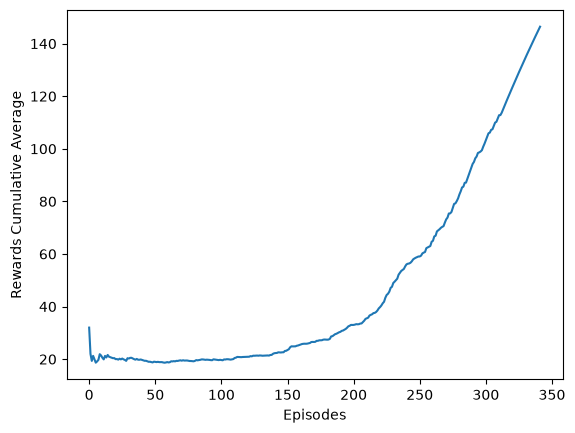

In [7]:
# 1. Classical PPO
classical_rewards = run(ActorCriticNN, cartpole_env, parameters)
plot_results(classical_rewards)

Actor parameters: 24

0:00:03.095371
1000 : Optimizing

0:00:03.236892
2000 : Optimizing

0:00:03.372641
3000 : Optimizing

0:00:03.152709
4000 : Optimizing

0:00:03.453118
5000 : Optimizing

0:00:03.331448
6000 : Optimizing

0:00:03.213331
7000 : Optimizing

0:00:03.115543
8000 : Optimizing

0:00:03.544841
9000 : Optimizing

0:00:03.116193
10000 : Optimizing

0:00:03.517604
11000 : Optimizing

0:00:03.086306
12000 : Optimizing

0:00:03.298981
13000 : Optimizing

0:00:03.248829
14000 : Optimizing

0:00:03.536812
15000 : Optimizing

0:00:03.561009
16000 : Optimizing

0:00:03.274637
17000 : Optimizing

0:00:03.201817
18000 : Optimizing

0:00:03.224537
19000 : Optimizing

0:00:03.067509
20000 : Optimizing

0:00:03.083676
21000 : Optimizing

0:00:03.151604
22000 : Optimizing

0:00:03.211006
23000 : Optimizing

0:00:03.473810
24000 : Optimizing

0:00:03.103772
25000 : Optimizing

0:00:03.041820
26000 : Optimizing

0:00:03.099053
27000 : Optimizing

0:00:03.179108
28000 : Optimizing

0:00:03

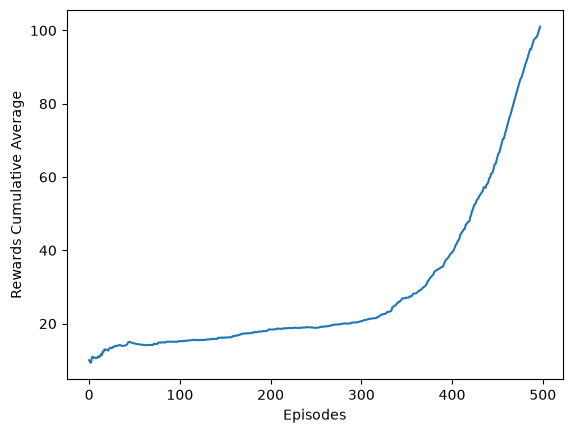

In [8]:
# 2. Qubit PPO
qubit_rewards = run(ActorQubitNN, cartpole_env, parameters)
plot_results(qubit_rewards)

## 6 - Conclusions
___

Running time
Performances
Parameters size
Memory consumption

## 7 - Follow-ups
___

Environments 2 and 3: Lunar Lander and Maze or Car Racing (Not doable in required time)

Photonic PPO (Non linear with deprecated SF or Piquasso)